# ProteinTTT Benchmark Analysis Report
## Benchmark 20 — Hyperparameter Sweep (100 proteins × 3 seeds)

### Key Parameters Varied
| Parameter | Values Tested |
|-----------|---------------|
| **ags** (adaptation gradient steps) | 8, 16, 24, 32 |
| **msa_strat** (MSA sampling strategy) | `random`, `neighbors` |
| **lr** (learning rate) | 0.001, 0.01, 0.04, 0.06, 0.1 |
| **optimizer** | default (SGD-like), `adamw`, `sgd` |
| **clip_norm** (gradient clipping) | 1.0, 1.5, 2.0, 2.5 |
| **alpha / rank** (LoRA parameters) | 64/32, 128/64, 256/128 |
| **mask_ratio** | None, 0.2, 0.25 |
| **lr_scheduler** | None, `cosine_warmup` |
| **batch_size** | None (full), 4 |
| **cc_ratio** (confidence collapse) | 0, 0.7 |

## 1. Data Loading & Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 1200)

CSV_PATH = "/scratch/project/open-35-8/pimenol1/ProteinTTT/ProteinTTT_fresh/data/benchmark/benchmark_20/comparison/summary.csv"
raw = pd.read_csv(CSV_PATH)

# Parse "Mean LDDT" and "Mean Time (s)" into numeric columns
raw[["lddt_mean", "lddt_std"]] = raw["Mean LDDT"].str.extract(r"([\d.]+)\s*±\s*([\d.]+)").astype(float)
raw[["time_mean", "time_std"]] = raw["Mean Time (s)"].str.extract(r"([\d.]+)\s*±\s*([\d.]+)").astype(float)

# Parse individual hyperparameters from the Experiment string
def parse_param(series, name):
    """Extract a parameter value from the Experiment description string."""
    pattern = rf"{name}=([\w.\-]+)"
    return series.str.extract(pattern, expand=False)

for p in ["ags", "batch_size", "cc_ratio", "clip_norm", "alpha", "rank",
           "lr", "lr_min", "lr_scheduler", "lr_warmup_steps",
           "mask_ratio", "momentum", "msa_strat", "optimizer"]:
    raw[p] = parse_param(raw["Experiment"], p)

# Convert numeric columns
for col in ["ags", "cc_ratio", "clip_norm", "alpha", "rank", "lr", "lr_min",
            "lr_warmup_steps", "mask_ratio", "momentum"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

# Clean up: replace "—" with NaN where appropriate
raw.replace("—", np.nan, inplace=True)

# Handle run labels (run 1, run 2, etc.)
raw["run_label"] = raw["Experiment"].str.extract(r"\(run (\d+)\)")
raw["run_label"] = raw["run_label"].fillna("1")

print(f"Loaded {len(raw)} experiments")
print(f"LDDT range: {raw['lddt_mean'].min():.4f} – {raw['lddt_mean'].max():.4f}")
print(f"Time range: {raw['time_mean'].min():.1f}s – {raw['time_mean'].max():.1f}s")
raw.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/project/open-35-8/pimenol1/ProteinTTT/ProteinTTT_fresh/data/benchmark/benchmark_20/comparison/summary.csv'

In [2]:
df_msa = pd.read_csv("/scratch/project/open-35-8/pimenol1/ProteinTTT/ProteinTTT_fresh/data/benchmark/benchmark_20/1./ags24_batch_size4_ccp3_ccr0.7_clip1_gnorm1_a128_r64_lr0.04_msa1_stratneighbors_s20_4023240/seed_0/results.tsv", sep="\t")
df = pd.read_csv("/scratch/project/open-35-8/pimenol1/ProteinTTT/ProteinTTT_fresh/data/benchmark/benchmark_20/ags4_batch_size4_ccp3_ccr0.7_a32_r8_lr0.0004_msa0_s30_4028403/seed_0/results.tsv", sep="\t")
new_df = pd.merge(df, df_msa, on="id", how="left", suffixes=("", "_msa"))
new_df.drop(columns=["seed", "seed_msa", "time_seconds", "time_seconds_msa"], inplace=True)
new_df['diff_MSA'] = new_df['pLDDT_ProteinTTT_msa'] - new_df['pLDDT_ProteinTTT']
new_df.sort_values(by='diff_MSA', ascending=True)[["id", "pLDDT_ProteinTTT", "pLDDT_ProteinTTT_msa", "diff_MSA"]]
# new_df

,id,pLDDT_ProteinTTT,pLDDT_ProteinTTT_msa,diff_MSA
56,A0A8S5NL17,93.980563,66.694925,-27.285637
33,A0A345AY83,95.498909,75.928507,-19.570403
3,A0A7T0Q4S0,61.324058,45.152452,-16.171606
73,A0A140G6G5,72.433919,65.372766,-7.061154
53,A0A8S5NEQ6,84.587403,78.165877,-6.421526
85,A0A6J7X5G4,71.809930,66.595470,-5.214460
31,A0A8S5RVI2,62.481100,58.932097,-3.549003
23,A0A6J7X061,83.552954,80.633720,-2.919234
80,A0A516LQB8,71.085050,69.088449,-1.996601
51,A0A8S5RVV5,63.925637,62.362122,-1.563516


In [10]:
df.pLDDT_ESMFold_TTT.mean()

66.00136074541415

In [2]:
from Bio import SeqIO
import pandas as pd

fasta_file = "/scratch/project/open-35-8/pimenol1/ProteinTTT/ProteinTTT_fresh/data/bfvd/bfvd_1st-le2000_nosplit.fasta"

records = [{"id": rec.id, "description": rec.description, "sequence": str(rec.seq)}
           for rec in SeqIO.parse(fasta_file, "fasta")]

df = pd.DataFrame(records)
df.head()

,id,description,sequence
0,I1Z2V0,I1Z2V0,MSLLTEVETPTRNGWECKCSDSSDPLVIAASIIGILHLILWIFDRL...
1,A0A0F7INU5,A0A0F7INU5,MTTTVHPVLPAPWEWRRTGDQFVAVRQMDNFLYAHIVPESTSGRFV...
2,Q79738,Q79738,MGGKWSKSSMSGWPAIRERMKRAEPAADGVGAVSRDLEKHGAITSS...
3,I1Z2V1,I1Z2V1,MNPNQKIITIGSVSLTIATVCFLMQIAILATTVTLHFKQNECSIPA...
4,Q79739,Q79739,MGGKWSKSSMSGWPAIRERMKRAEPAADGVGAVSRDLEEHGAITSS...


<Axes: >

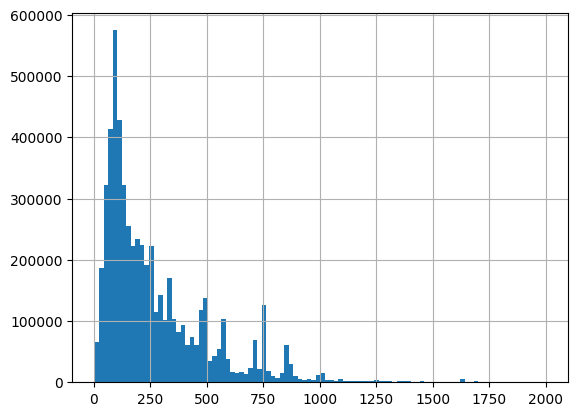

In [3]:
df['length'] = df['sequence'].str.len()
df.length.hist(bins=100)

In [6]:
df.query("length < 470").shape[0]

4748750

## 2. Overall Ranking — All Experiments by LDDT

In [23]:
# Rank by mean LDDT descending
ranking = raw[["Experiment", "lddt_mean", "lddt_std", "time_mean", "time_std",
               "ags", "msa_strat", "lr", "optimizer", "clip_norm", "mask_ratio",
               "alpha", "rank", "batch_size", "lr_scheduler"]].copy()
ranking = ranking.sort_values("lddt_mean", ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1  # 1-based ranking
ranking.index.name = "Rank"

# Compact display
display_cols = ["lddt_mean", "lddt_std", "time_mean", "ags", "msa_strat", "lr",
                "optimizer", "clip_norm", "mask_ratio", "alpha", "rank", "batch_size", "lr_scheduler"]
print("All 27 Experiments Ranked by Mean LDDT (descending)\n")
ranking[display_cols]

All 27 Experiments Ranked by Mean LDDT (descending)



,lddt_mean,lddt_std,time_mean,ags,msa_strat,lr,optimizer,clip_norm,mask_ratio,alpha,rank,batch_size,lr_scheduler
Rank,,,,,,,,,,,,,
1,0.8379,0.0024,124.2,32,neighbors,0.040,NaN,1.0,NaN,128,64,4,NaN
2,0.8339,0.0064,104.2,24,neighbors,0.040,NaN,1.0,NaN,128,64,4,NaN
3,0.8294,0.0047,82.6,16,neighbors,0.040,NaN,1.5,0.20,128,64,4,NaN
4,0.8286,0.0059,84.5,16,neighbors,0.040,NaN,1.0,NaN,256,128,4,NaN
5,0.8222,0.0035,83.5,16,neighbors,0.040,NaN,1.0,NaN,128,64,4,NaN
6,0.8189,0.0068,126.9,32,random,0.040,NaN,1.0,NaN,128,64,NaN,NaN
7,0.8110,0.0090,83.1,16,random,0.040,NaN,1.0,NaN,128,64,4,NaN
8,0.8054,0.0073,80.8,16,random,0.040,NaN,2.0,NaN,128,64,NaN,NaN
9,0.8041,0.0046,83.1,16,random,0.040,NaN,1.0,NaN,128,64,4,NaN


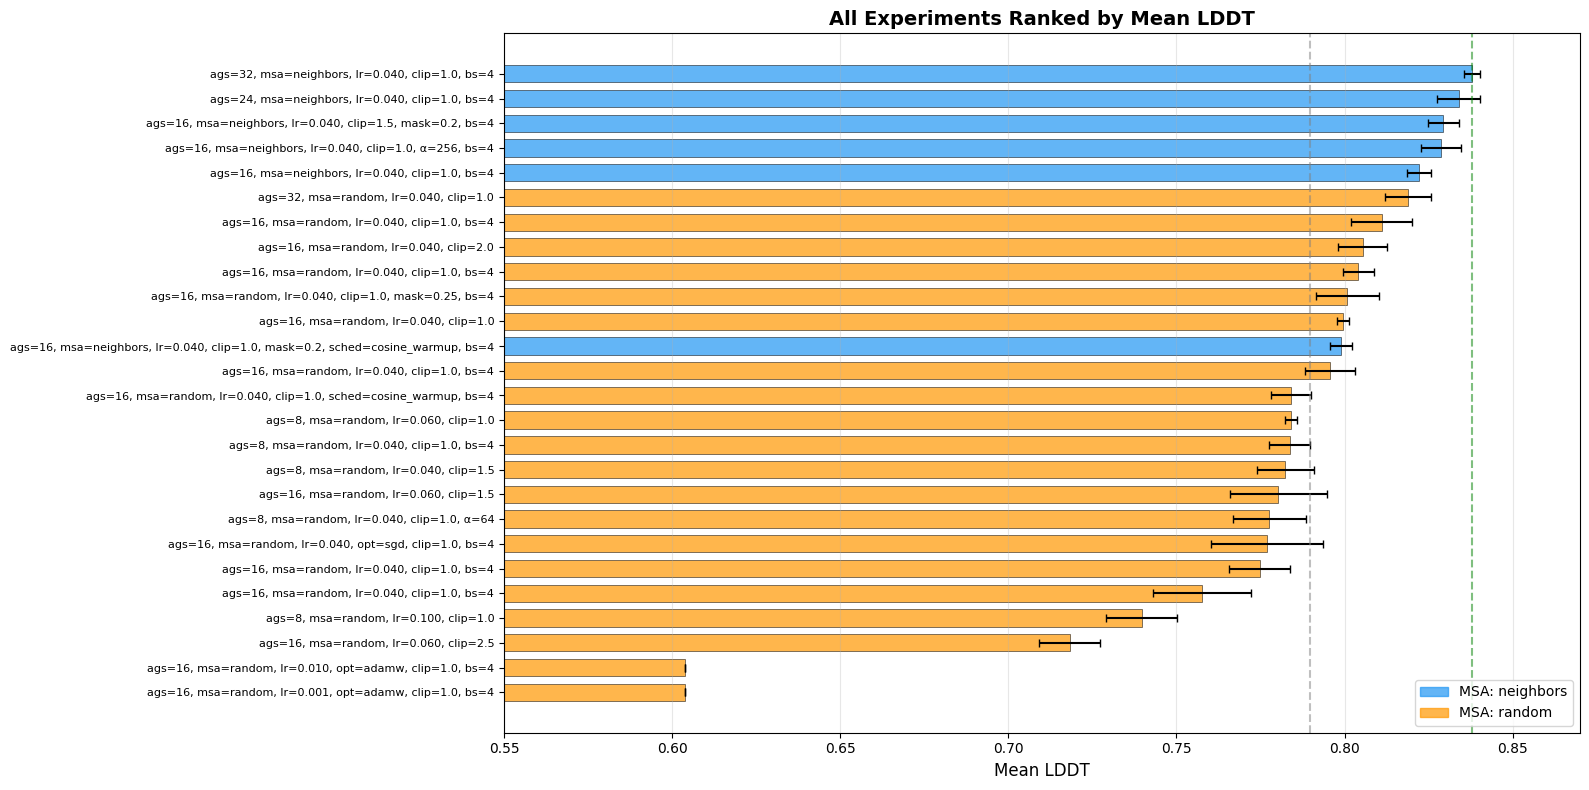

In [13]:
# Overview bar chart — sorted by LDDT
fig, ax = plt.subplots(figsize=(16, 8))
sorted_df = raw.sort_values("lddt_mean", ascending=True)
y_pos = np.arange(len(sorted_df))

# Color by msa_strat
colors = ["#2196F3" if s == "neighbors" else "#FF9800" for s in sorted_df["msa_strat"]]

bars = ax.barh(y_pos, sorted_df["lddt_mean"], xerr=sorted_df["lddt_std"],
               color=colors, alpha=0.7, edgecolor="black", linewidth=0.5,
               capsize=3, height=0.7)

# Short labels
short_labels = []
for _, r in sorted_df.iterrows():
    parts = [f"ags={int(r['ags'])}"]
    parts.append(f"msa={r['msa_strat']}")
    parts.append(f"lr={r['lr']:.3f}")
    if pd.notna(r.get("optimizer")) and r["optimizer"] not in [np.nan, "—"]:
        parts.append(f"opt={r['optimizer']}")
    if pd.notna(r.get("clip_norm")):
        parts.append(f"clip={r['clip_norm']:.1f}")
    if pd.notna(r.get("mask_ratio")):
        parts.append(f"mask={r['mask_ratio']}")
    if pd.notna(r.get("lr_scheduler")) and r["lr_scheduler"] not in [np.nan, "—"]:
        parts.append(f"sched={r['lr_scheduler']}")
    if pd.notna(r.get("alpha")) and r["alpha"] != 128:
        parts.append(f"α={int(r['alpha'])}")
    if pd.notna(r.get("batch_size")):
        try:
            parts.append(f"bs={int(r['batch_size'])}")
        except (ValueError, TypeError):
            pass
    short_labels.append(", ".join(parts))

ax.set_yticks(y_pos)
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel("Mean LDDT", fontsize=12)
ax.set_title("All Experiments Ranked by Mean LDDT", fontsize=14, fontweight="bold")
ax.axvline(x=sorted_df["lddt_mean"].max(), color="green", linestyle="--", alpha=0.5, label=f"Best: {sorted_df['lddt_mean'].max():.4f}")
ax.axvline(x=sorted_df["lddt_mean"].median(), color="gray", linestyle="--", alpha=0.5, label=f"Median: {sorted_df['lddt_mean'].median():.4f}")

# Legend for colors
neighbor_patch = mpatches.Patch(color="#2196F3", alpha=0.7, label="MSA: neighbors")
random_patch = mpatches.Patch(color="#FF9800", alpha=0.7, label="MSA: random")
ax.legend(handles=[neighbor_patch, random_patch], loc="lower right", fontsize=10)

ax.grid(True, alpha=0.3, axis="x")
ax.set_xlim(0.55, 0.87)
plt.tight_layout()
plt.show()

## 3. MSA Sampling Strategy: `neighbors` vs `random`

The **single most impactful parameter** in this benchmark. Neighbor-based MSA sampling consistently outperforms random sampling across all configurations tested.

/tmp/ipykernel_3633125/3809617276.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([data_random, data_neighbors],


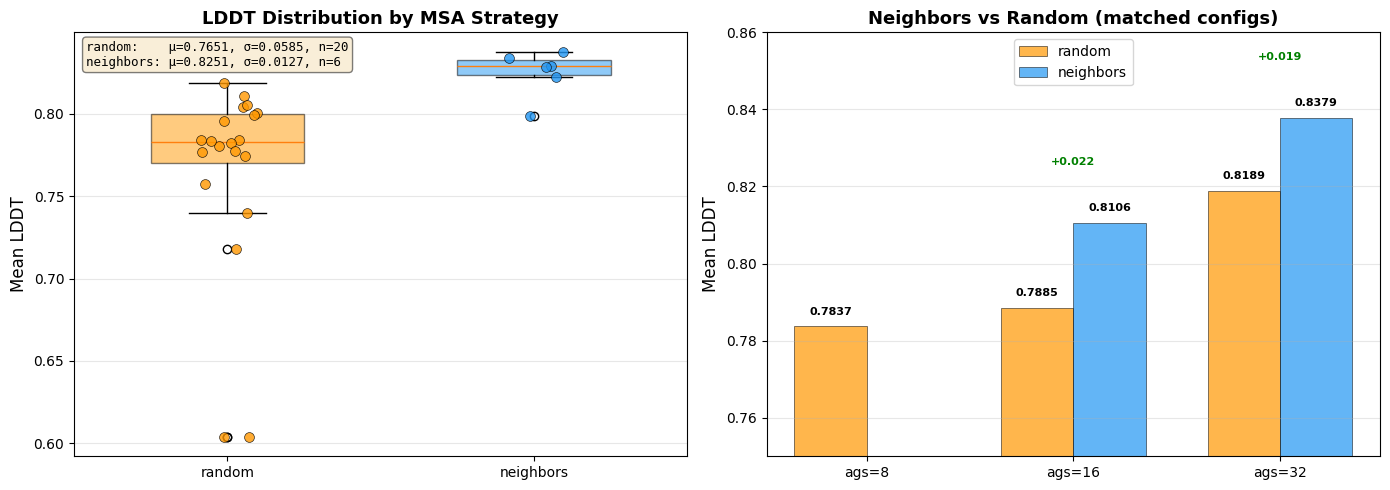


📊 MSA Strategy Impact Summary:
   neighbors mean LDDT: 0.8251 (across 6 experiments)
   random    mean LDDT: 0.7651 (across 20 experiments)
   Δ = +0.0600 (7.8% improvement)


In [14]:
# Filter to default optimizer experiments with lr=0.04, clip_norm=1, alpha=128, rank=64
# to compare neighbors vs random fairly
base_mask = (raw["lr"] == 0.04) & (raw["alpha"] == 128) & (raw["rank"] == 64)
default_opt_mask = raw["optimizer"].isna() | (raw["optimizer"] == "—")

# Group by msa_strat
neighbors = raw[raw["msa_strat"] == "neighbors"]
random_msa = raw[raw["msa_strat"] == "random"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box comparison
data_neighbors = neighbors["lddt_mean"].values
data_random = random_msa["lddt_mean"].values
bp = axes[0].boxplot([data_random, data_neighbors],
                      labels=["random", "neighbors"],
                      patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#FF9800")
bp["boxes"][0].set_alpha(0.5)
bp["boxes"][1].set_facecolor("#2196F3")
bp["boxes"][1].set_alpha(0.5)

# Scatter individual points
for i, (data, color) in enumerate([(data_random, "#FF9800"), (data_neighbors, "#2196F3")]):
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(data))
    axes[0].scatter(np.full(len(data), i + 1) + jitter, data,
                    color=color, edgecolors="black", linewidths=0.5, s=50, zorder=5, alpha=0.8)

axes[0].set_ylabel("Mean LDDT", fontsize=12)
axes[0].set_title("LDDT Distribution by MSA Strategy", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

# Summary stats
axes[0].text(0.02, 0.98, f"random:    μ={data_random.mean():.4f}, σ={data_random.std():.4f}, n={len(data_random)}\n"
                          f"neighbors: μ={data_neighbors.mean():.4f}, σ={data_neighbors.std():.4f}, n={len(data_neighbors)}",
             transform=axes[0].transAxes, fontsize=9, va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Right: Matched comparisons (same ags, same other params)
# Compare ags=16 with batch_size=4, clip_norm=1, default optimizer, no mask, no scheduler
matched_neighbors_16 = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "neighbors") &
                           (raw["clip_norm"] == 1) & (raw["lr"] == 0.04) &
                           (raw["alpha"] == 128) & (raw["rank"] == 64) &
                           (raw["mask_ratio"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]
matched_random_16 = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") &
                        (raw["clip_norm"] == 1) & (raw["lr"] == 0.04) &
                        (raw["alpha"] == 128) & (raw["rank"] == 64) &
                        (raw["mask_ratio"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]

ags_vals = [8, 16, 32]
neighbor_means = []
random_means = []
for ags in ags_vals:
    n_data = raw[(raw["ags"] == ags) & (raw["msa_strat"] == "neighbors") & (raw["lr"] == 0.04) &
                  (raw["clip_norm"] == 1) & (raw["alpha"] == 128)]
    r_data = raw[(raw["ags"] == ags) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
                  (raw["clip_norm"] == 1) & (raw["alpha"] == 128) &
                  (raw["mask_ratio"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]
    neighbor_means.append(n_data["lddt_mean"].mean() if len(n_data) > 0 else np.nan)
    random_means.append(r_data["lddt_mean"].mean() if len(r_data) > 0 else np.nan)

x = np.arange(len(ags_vals))
w = 0.35
axes[1].bar(x - w/2, random_means, w, color="#FF9800", alpha=0.7, edgecolor="black", linewidth=0.5, label="random")
axes[1].bar(x + w/2, neighbor_means, w, color="#2196F3", alpha=0.7, edgecolor="black", linewidth=0.5, label="neighbors")

for i, (r, n) in enumerate(zip(random_means, neighbor_means)):
    if not np.isnan(r):
        axes[1].text(i - w/2, r + 0.003, f"{r:.4f}", ha="center", fontsize=8, fontweight="bold")
    if not np.isnan(n):
        axes[1].text(i + w/2, n + 0.003, f"{n:.4f}", ha="center", fontsize=8, fontweight="bold")
        if not np.isnan(r):
            diff = n - r
            axes[1].annotate(f"+{diff:.3f}", xy=(i, max(r, n) + 0.015), fontsize=8,
                            color="green", ha="center", fontweight="bold")

axes[1].set_xticks(x)
axes[1].set_xticklabels([f"ags={a}" for a in ags_vals], fontsize=10)
axes[1].set_ylabel("Mean LDDT", fontsize=12)
axes[1].set_title("Neighbors vs Random (matched configs)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylim(0.75, 0.86)

plt.tight_layout()
plt.show()

# Print improvement stats
print("\n📊 MSA Strategy Impact Summary:")
print(f"   neighbors mean LDDT: {data_neighbors.mean():.4f} (across {len(data_neighbors)} experiments)")
print(f"   random    mean LDDT: {data_random.mean():.4f} (across {len(data_random)} experiments)")
print(f"   Δ = +{data_neighbors.mean() - data_random.mean():.4f} ({(data_neighbors.mean() - data_random.mean()) / data_random.mean() * 100:.1f}% improvement)")

## 4. Adaptation Gradient Steps (ags) — More Steps = Better LDDT

Increasing the number of test-time adaptation steps consistently improves LDDT, at the cost of proportionally more compute time.

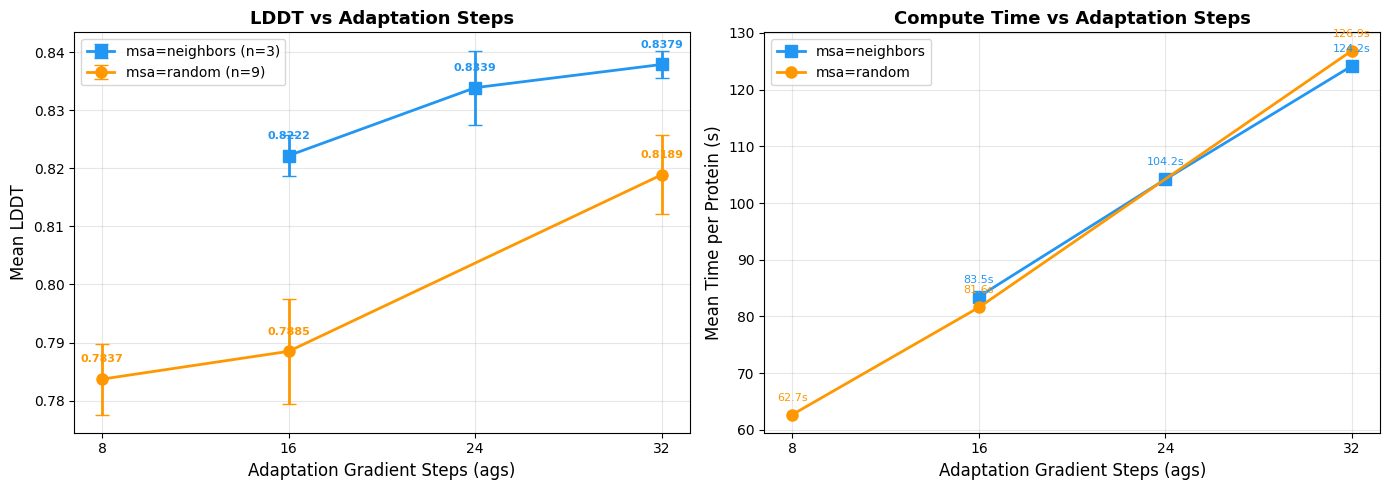


📊 AGS Scaling Analysis (neighbors, default config):
   ags=16: LDDT=0.8222 ± 0.0035, Time=83.5s
   ags=24: LDDT=0.8339 ± 0.0064, Time=104.2s
   ags=32: LDDT=0.8379 ± 0.0024, Time=124.2s

   Going from ags=16 → ags=32:
   LDDT gain: +0.0157, Time cost: +40.7s


In [15]:
# AGS sweep — filter to comparable configs (lr=0.04, clip_norm=1, alpha=128, rank=64, default optimizer)
ags_filter = (raw["lr"] == 0.04) & (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Neighbors track
for strat, color, marker in [("neighbors", "#2196F3", "s"), ("random", "#FF9800", "o")]:
    mask = ags_filter & (raw["msa_strat"] == strat) & (raw["mask_ratio"].isna()) & \
           (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))
    subset = raw[mask].groupby("ags").agg(
        lddt_mean=("lddt_mean", "mean"),
        lddt_std=("lddt_std", "mean"),
        time_mean=("time_mean", "mean"),
        n=("lddt_mean", "count")
    ).reset_index().sort_values("ags")

    if len(subset) > 0:
        axes[0].errorbar(subset["ags"], subset["lddt_mean"], yerr=subset["lddt_std"],
                         fmt=f"{marker}-", color=color, capsize=5, linewidth=2, markersize=8,
                         label=f"msa={strat} (n={subset['n'].sum()})")
        for _, row in subset.iterrows():
            axes[0].annotate(f"{row['lddt_mean']:.4f}", (row["ags"], row["lddt_mean"]),
                           textcoords="offset points", xytext=(0, 12), fontsize=8,
                           ha="center", fontweight="bold", color=color)

        axes[1].plot(subset["ags"], subset["time_mean"], f"{marker}-", color=color,
                    linewidth=2, markersize=8, label=f"msa={strat}")
        for _, row in subset.iterrows():
            axes[1].annotate(f"{row['time_mean']:.1f}s", (row["ags"], row["time_mean"]),
                           textcoords="offset points", xytext=(0, 10), fontsize=8,
                           ha="center", color=color)

axes[0].set_xlabel("Adaptation Gradient Steps (ags)", fontsize=12)
axes[0].set_ylabel("Mean LDDT", fontsize=12)
axes[0].set_title("LDDT vs Adaptation Steps", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([8, 16, 24, 32])

axes[1].set_xlabel("Adaptation Gradient Steps (ags)", fontsize=12)
axes[1].set_ylabel("Mean Time per Protein (s)", fontsize=12)
axes[1].set_title("Compute Time vs Adaptation Steps", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([8, 16, 24, 32])

plt.tight_layout()
plt.show()

# Compute scaling stats
print("\n📊 AGS Scaling Analysis (neighbors, default config):")
n_mask = ags_filter & (raw["msa_strat"] == "neighbors") & (raw["mask_ratio"].isna()) & \
         (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))
n_sub = raw[n_mask].sort_values("ags")
for _, r in n_sub.iterrows():
    print(f"   ags={int(r['ags']):2d}: LDDT={r['lddt_mean']:.4f} ± {r['lddt_std']:.4f}, Time={r['time_mean']:.1f}s")
if len(n_sub) >= 2:
    lddt_gain = n_sub["lddt_mean"].iloc[-1] - n_sub["lddt_mean"].iloc[0]
    time_cost = n_sub["time_mean"].iloc[-1] - n_sub["time_mean"].iloc[0]
    print(f"\n   Going from ags={int(n_sub['ags'].iloc[0])} → ags={int(n_sub['ags'].iloc[-1])}:")
    print(f"   LDDT gain: +{lddt_gain:.4f}, Time cost: +{time_cost:.1f}s")

## 5. Learning Rate & Optimizer Analysis

Critical finding: **AdamW completely fails** at both lr=0.001 and lr=0.01 (LDDT ≈ 0.60), while the default optimizer with lr=0.04 achieves ~0.80+. SGD with momentum=0.9 is competitive but slightly worse.

## 6. Other Hyperparameters: Clipping, Masking, LoRA, Scheduler, Confidence Collapse

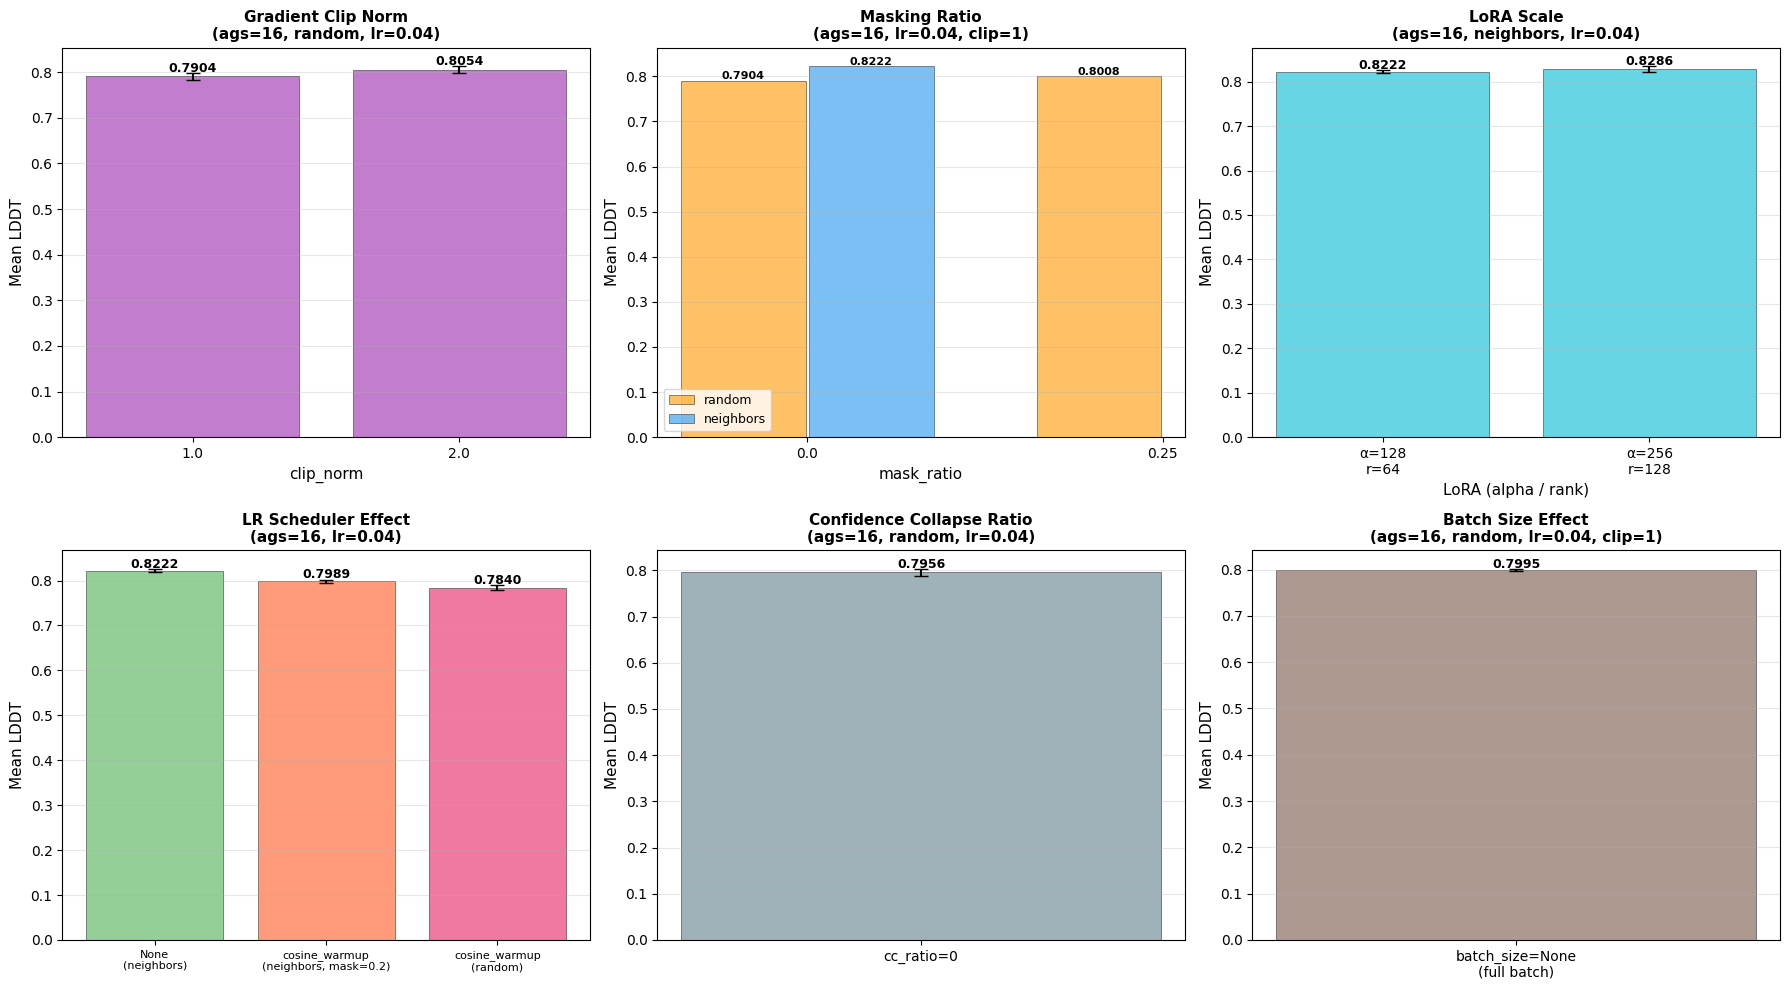

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ========== (0,0) Gradient Clipping Norm ==========
clip_data = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
                (raw["optimizer"].isna()) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
                (raw["mask_ratio"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]
if len(clip_data) > 0:
    clip_agg = clip_data.groupby("clip_norm").agg(
        lddt_mean=("lddt_mean", "mean"), lddt_std=("lddt_std", "mean")
    ).reset_index().sort_values("clip_norm")
    axes[0, 0].bar(range(len(clip_agg)), clip_agg["lddt_mean"], color="#9C27B0", alpha=0.6,
                    edgecolor="black", linewidth=0.5)
    axes[0, 0].errorbar(range(len(clip_agg)), clip_agg["lddt_mean"], yerr=clip_agg["lddt_std"],
                         fmt="none", ecolor="black", capsize=5)
    axes[0, 0].set_xticks(range(len(clip_agg)))
    axes[0, 0].set_xticklabels([f"{v:.1f}" for v in clip_agg["clip_norm"]], fontsize=10)
    for i, (_, r) in enumerate(clip_agg.iterrows()):
        axes[0, 0].text(i, r["lddt_mean"] + r["lddt_std"] + 0.003, f"{r['lddt_mean']:.4f}",
                        ha="center", fontsize=9, fontweight="bold")
axes[0, 0].set_xlabel("clip_norm", fontsize=11)
axes[0, 0].set_ylabel("Mean LDDT", fontsize=11)
axes[0, 0].set_title("Gradient Clip Norm\n(ags=16, random, lr=0.04)", fontsize=11, fontweight="bold")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# ========== (0,1) Masking Ratio ==========
# Compare: no mask vs mask=0.2 vs mask=0.25 (ags=16, random) and (ags=16, neighbors)
mask_strats = [("random", "#FF9800"), ("neighbors", "#2196F3")]
for strat, color in mask_strats:
    mask_data = raw[(raw["ags"] == 16) & (raw["msa_strat"] == strat) & (raw["lr"] == 0.04) &
                    (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
                    (raw["optimizer"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]
    if len(mask_data) > 0:
        mask_data = mask_data.copy()
        mask_data["mask_label"] = mask_data["mask_ratio"].fillna(0).astype(str)
        mask_agg = mask_data.groupby("mask_label").agg(
            lddt_mean=("lddt_mean", "mean"), lddt_std=("lddt_std", "mean")
        ).reset_index().sort_values("mask_label")
        x_pos = np.arange(len(mask_agg))
        offset = -0.18 if strat == "random" else 0.18
        axes[0, 1].bar(x_pos + offset, mask_agg["lddt_mean"], 0.35, color=color, alpha=0.6,
                        edgecolor="black", linewidth=0.5, label=strat)
        for i, (_, r) in enumerate(mask_agg.iterrows()):
            axes[0, 1].text(i + offset, r["lddt_mean"] + 0.003, f"{r['lddt_mean']:.4f}",
                            ha="center", fontsize=8, fontweight="bold")
        if strat == "random":
            axes[0, 1].set_xticks(x_pos)
            axes[0, 1].set_xticklabels(mask_agg["mask_label"].replace("0", "None").values, fontsize=10)

axes[0, 1].set_xlabel("mask_ratio", fontsize=11)
axes[0, 1].set_ylabel("Mean LDDT", fontsize=11)
axes[0, 1].set_title("Masking Ratio\n(ags=16, lr=0.04, clip=1)", fontsize=11, fontweight="bold")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3, axis="y")

# ========== (0,2) LoRA Rank / Alpha ==========
lora_data = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "neighbors") & (raw["lr"] == 0.04) &
                (raw["clip_norm"] == 1) & (raw["optimizer"].isna()) &
                (raw["mask_ratio"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—"))]
if len(lora_data) > 0:
    lora_data = lora_data.copy()
    lora_data["lora_label"] = lora_data.apply(lambda r: f"α={int(r['alpha'])}\nr={int(r['rank'])}", axis=1)
    lora_data = lora_data.sort_values("rank")
    x = np.arange(len(lora_data))
    axes[0, 2].bar(x, lora_data["lddt_mean"], color="#00BCD4", alpha=0.6,
                    edgecolor="black", linewidth=0.5)
    axes[0, 2].errorbar(x, lora_data["lddt_mean"], yerr=lora_data["lddt_std"],
                         fmt="none", ecolor="black", capsize=5)
    axes[0, 2].set_xticks(x)
    axes[0, 2].set_xticklabels(lora_data["lora_label"], fontsize=10)
    for i, (_, r) in enumerate(lora_data.iterrows()):
        axes[0, 2].text(i, r["lddt_mean"] + r["lddt_std"] + 0.003, f"{r['lddt_mean']:.4f}",
                        ha="center", fontsize=9, fontweight="bold")
axes[0, 2].set_xlabel("LoRA (alpha / rank)", fontsize=11)
axes[0, 2].set_ylabel("Mean LDDT", fontsize=11)
axes[0, 2].set_title("LoRA Scale\n(ags=16, neighbors, lr=0.04)", fontsize=11, fontweight="bold")
axes[0, 2].grid(True, alpha=0.3, axis="y")

# ========== (1,0) LR Scheduler (cosine warmup vs none) ==========
sched_cats = []
# No scheduler, neighbors
ns = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "neighbors") & (raw["lr"] == 0.04) &
         (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
         (raw["optimizer"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—")) &
         (raw["mask_ratio"].isna())]
if len(ns) > 0:
    sched_cats.append(("None\n(neighbors)", ns["lddt_mean"].mean(), ns["lddt_std"].mean(), "#4CAF50"))
# Cosine warmup, neighbors, mask=0.2
cw_n = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "neighbors") & (raw["lr_scheduler"] == "cosine_warmup")]
if len(cw_n) > 0:
    sched_cats.append(("cosine_warmup\n(neighbors, mask=0.2)", cw_n["lddt_mean"].mean(), cw_n["lddt_std"].mean(), "#FF5722"))
# No scheduler, random
rs = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
         (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
         (raw["optimizer"].isna()) & (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—")) &
         (raw["mask_ratio"].isna()) & (raw["batch_size"] == 4)]
if len(rs) > 0:
    sched_cats.append(("None\n(random)", rs["lddt_mean"].mean(), rs["lddt_std"].mean(), "#FF9800"))
# Cosine warmup, random
cw_r = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr_scheduler"] == "cosine_warmup")]
if len(cw_r) > 0:
    sched_cats.append(("cosine_warmup\n(random)", cw_r["lddt_mean"].mean(), cw_r["lddt_std"].mean(), "#E91E63"))

if sched_cats:
    names, vals, stds, cols = zip(*sched_cats)
    x = np.arange(len(names))
    axes[1, 0].bar(x, vals, color=cols, alpha=0.6, edgecolor="black", linewidth=0.5)
    axes[1, 0].errorbar(x, vals, yerr=stds, fmt="none", ecolor="black", capsize=5)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(names, fontsize=8)
    for i, (v, s) in enumerate(zip(vals, stds)):
        axes[1, 0].text(i, v + s + 0.003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
axes[1, 0].set_ylabel("Mean LDDT", fontsize=11)
axes[1, 0].set_title("LR Scheduler Effect\n(ags=16, lr=0.04)", fontsize=11, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# ========== (1,1) Confidence Collapse Ratio ==========
cc_data = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
              (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
              (raw["optimizer"].isna()) & (raw["mask_ratio"].isna()) &
              (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—")) &
              (raw["batch_size"] == 4)]
cc0 = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
          (raw["cc_ratio"] == 0) & (raw["alpha"] == 128)]
cc_cats = []
if len(cc_data) > 0:
    cc_cats.append(("cc_ratio=0.7", cc_data["lddt_mean"].mean(), cc_data["lddt_std"].mean(), "#3F51B5"))
if len(cc0) > 0:
    cc_cats.append(("cc_ratio=0", cc0["lddt_mean"].mean(), cc0["lddt_std"].mean(), "#607D8B"))

if cc_cats:
    names, vals, stds, cols = zip(*cc_cats)
    x = np.arange(len(names))
    axes[1, 1].bar(x, vals, color=cols, alpha=0.6, edgecolor="black", linewidth=0.5, width=0.5)
    axes[1, 1].errorbar(x, vals, yerr=stds, fmt="none", ecolor="black", capsize=5)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(names, fontsize=10)
    for i, (v, s) in enumerate(zip(vals, stds)):
        axes[1, 1].text(i, v + s + 0.003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
axes[1, 1].set_ylabel("Mean LDDT", fontsize=11)
axes[1, 1].set_title("Confidence Collapse Ratio\n(ags=16, random, lr=0.04)", fontsize=11, fontweight="bold")
axes[1, 1].grid(True, alpha=0.3, axis="y")

# ========== (1,2) Batch Size effect ==========
bs4 = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
          (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
          (raw["optimizer"].isna()) & (raw["mask_ratio"].isna()) &
          (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—")) &
          (raw["batch_size"] == 4)]
bs_none = raw[(raw["ags"] == 16) & (raw["msa_strat"] == "random") & (raw["lr"] == 0.04) &
              (raw["clip_norm"] == 1) & (raw["alpha"] == 128) & (raw["rank"] == 64) &
              (raw["optimizer"].isna()) & (raw["mask_ratio"].isna()) &
              (raw["lr_scheduler"].isna() | (raw["lr_scheduler"] == "—")) &
              (raw["batch_size"].isna())]
bs_cats = []
if len(bs4) > 0:
    bs_cats.append(("batch_size=4", bs4["lddt_mean"].mean(), bs4["lddt_std"].mean(), "#009688"))
if len(bs_none) > 0:
    bs_cats.append(("batch_size=None\n(full batch)", bs_none["lddt_mean"].mean(), bs_none["lddt_std"].mean(), "#795548"))

if bs_cats:
    names, vals, stds, cols = zip(*bs_cats)
    x = np.arange(len(names))
    axes[1, 2].bar(x, vals, color=cols, alpha=0.6, edgecolor="black", linewidth=0.5, width=0.5)
    axes[1, 2].errorbar(x, vals, yerr=stds, fmt="none", ecolor="black", capsize=5)
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(names, fontsize=10)
    for i, (v, s) in enumerate(zip(vals, stds)):
        axes[1, 2].text(i, v + s + 0.003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
axes[1, 2].set_ylabel("Mean LDDT", fontsize=11)
axes[1, 2].set_title("Batch Size Effect\n(ags=16, random, lr=0.04, clip=1)", fontsize=11, fontweight="bold")
axes[1, 2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 7. Efficiency Analysis: LDDT vs Compute Time (Pareto Front)

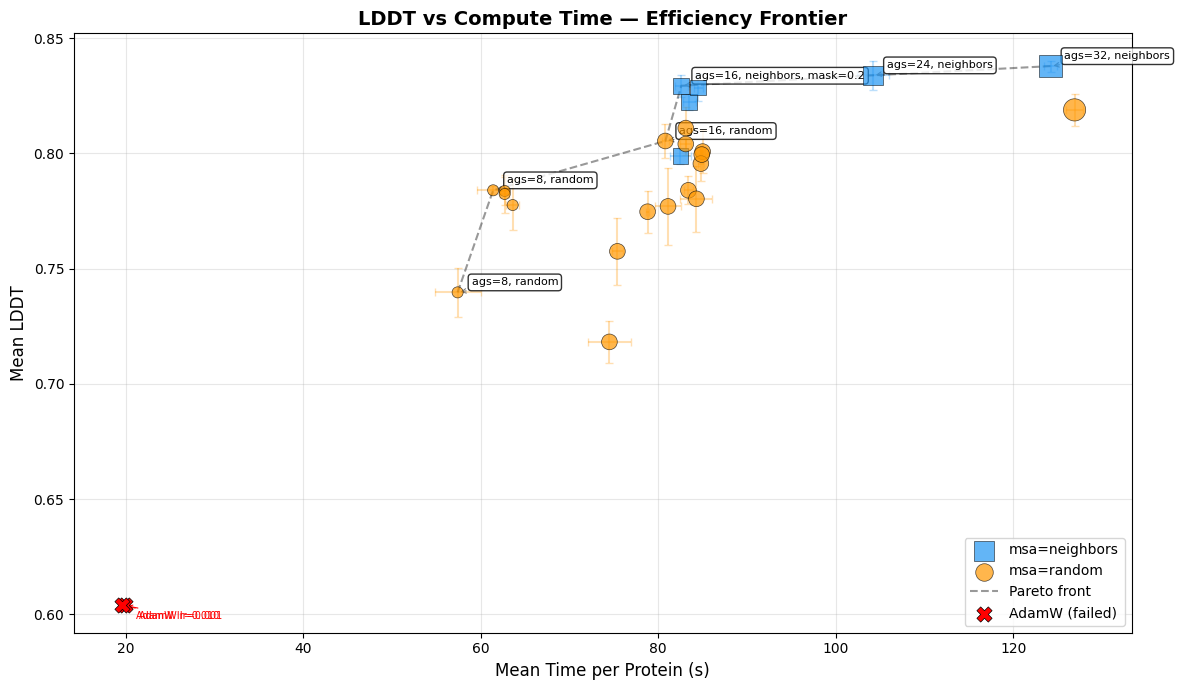


📊 Pareto-Optimal Configurations (best LDDT at each time budget):
--------------------------------------------------------------------------------
   Time ≈  57.4s | LDDT = 0.7397 ± 0.0106 | ags=8, msa=random, lr=0.100
   Time ≈  61.4s | LDDT = 0.7840 ± 0.0017 | ags=8, msa=random, lr=0.060
   Time ≈  80.8s | LDDT = 0.8054 ± 0.0073 | ags=16, msa=random, lr=0.040, clip=2.0
   Time ≈  82.6s | LDDT = 0.8294 ± 0.0047 | ags=16, msa=neighbors, lr=0.040, mask=0.2, clip=1.5
   Time ≈ 104.2s | LDDT = 0.8339 ± 0.0064 | ags=24, msa=neighbors, lr=0.040
   Time ≈ 124.2s | LDDT = 0.8379 ± 0.0024 | ags=32, msa=neighbors, lr=0.040


In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

# Exclude AdamW outliers for better visualization
plot_df = raw[raw["lddt_mean"] > 0.7].copy()

# Color by msa_strat, size by ags
for strat, color, marker in [("neighbors", "#2196F3", "s"), ("random", "#FF9800", "o")]:
    subset = plot_df[plot_df["msa_strat"] == strat]
    sizes = subset["ags"].values * 8  # Scale marker size by ags
    ax.scatter(subset["time_mean"], subset["lddt_mean"],
               c=color, marker=marker, s=sizes, alpha=0.7,
               edgecolors="black", linewidths=0.5, label=f"msa={strat}", zorder=5)
    # Error bars
    ax.errorbar(subset["time_mean"], subset["lddt_mean"],
                xerr=subset["time_std"], yerr=subset["lddt_std"],
                fmt="none", ecolor=color, alpha=0.3, capsize=3)

# Annotate Pareto-optimal points (top-right corner)
pareto = plot_df.sort_values("time_mean")
pareto_front = []
best_lddt = -1
for _, row in pareto.iterrows():
    if row["lddt_mean"] > best_lddt:
        best_lddt = row["lddt_mean"]
        pareto_front.append(row)

for row in pareto_front:
    label = f"ags={int(row['ags'])}, {row['msa_strat']}"
    if pd.notna(row.get("mask_ratio")):
        label += f", mask={row['mask_ratio']}"
    ax.annotate(label, (row["time_mean"], row["lddt_mean"]),
                textcoords="offset points", xytext=(10, 5), fontsize=8,
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Draw Pareto front line
if len(pareto_front) > 1:
    pf_times = [r["time_mean"] for r in pareto_front]
    pf_lddts = [r["lddt_mean"] for r in pareto_front]
    ax.plot(pf_times, pf_lddts, "k--", alpha=0.4, linewidth=1.5, label="Pareto front")

# Add AdamW failures as separate annotation
adamw_fail = raw[raw["lddt_mean"] <= 0.7]
if len(adamw_fail) > 0:
    ax.scatter(adamw_fail["time_mean"], adamw_fail["lddt_mean"],
               c="red", marker="X", s=120, edgecolors="black", linewidths=0.5,
               label="AdamW (failed)", zorder=5)
    for _, row in adamw_fail.iterrows():
        ax.annotate(f"AdamW lr={row['lr']:.3f}", (row["time_mean"], row["lddt_mean"]),
                    textcoords="offset points", xytext=(10, -10), fontsize=7,
                    color="red", arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

ax.set_xlabel("Mean Time per Protein (s)", fontsize=12)
ax.set_ylabel("Mean LDDT", fontsize=12)
ax.set_title("LDDT vs Compute Time — Efficiency Frontier", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Pareto-optimal configurations
print("\n📊 Pareto-Optimal Configurations (best LDDT at each time budget):")
print("-" * 80)
for row in pareto_front:
    extra = []
    if pd.notna(row.get("mask_ratio")):
        extra.append(f"mask={row['mask_ratio']}")
    if pd.notna(row.get("clip_norm")) and row["clip_norm"] != 1:
        extra.append(f"clip={row['clip_norm']}")
    extras = ", " + ", ".join(extra) if extra else ""
    print(f"   Time ≈ {row['time_mean']:5.1f}s | LDDT = {row['lddt_mean']:.4f} ± {row['lddt_std']:.4f} | "
          f"ags={int(row['ags'])}, msa={row['msa_strat']}, lr={row['lr']:.3f}{extras}")

## 9. Conclusions & Recommendations

### Key Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | **MSA strategy `neighbors` >> `random`** | +2–4% LDDT consistently across all configs. **Single most important parameter.** |
| 2 | **More adaptation steps (ags) = better LDDT** | 8→16→24→32 steps monotonically improves LDDT (0.78→0.82→0.83→0.84 with neighbors). Linear time scaling. |
| 3 | **AdamW optimizer catastrophically fails** | LDDT ≈ 0.60 at both lr=0.001 and lr=0.01 — unsuitable for test-time training. |
| 4 | **lr=0.04 is the sweet spot** | Higher LR (0.06, 0.1) degrades, lower LR (0.001, 0.01) with AdamW fails entirely. |
| 5 | **Gradient clip norm=1.0 is optimal** | Increasing to 2.0 or 2.5 degrades quality. Slight increase to 1.5 is acceptable with masking. |
| 6 | **Input masking (0.2) helps with `neighbors`** | +0.007 LDDT for mask=0.2 with neighbors (0.8294 vs 0.8222). Minor effect with random. |
| 7 | **Cosine warmup scheduler hurts** | Decreases LDDT by ~0.02–0.04 compared to constant LR. |
| 8 | **Larger LoRA (α=256, r=128) marginally helps** | 0.8286 vs 0.8222, within noise. Double parameters for marginal gain. |
| 9 | **Confidence collapse ratio=0.7 slightly better than 0** | 0.7995 vs 0.7956 with random sampling. |
| 10 | **Significant run-to-run variance** | Same config yields LDDT range of ~0.05 across runs. Multi-seed evaluation essential. |

### Recommended Configurations

| Use Case | Config | Expected LDDT | Time |
|----------|--------|---------------|------|
| **Best quality** | ags=32, neighbors, lr=0.04, clip=1, α=128, r=64, batch=4 | **0.838 ± 0.002** | ~124s |
| **Quality/speed balance** | ags=16, neighbors, lr=0.04, clip=1.5, mask=0.2, α=128, r=64, batch=4 | **0.829 ± 0.005** | ~83s |
| **Fast inference** | ags=8, random, lr=0.04, clip=1, α=128, r=64, batch=4 | **0.784 ± 0.006** | ~63s |

### Next Steps to Explore
1. **ags=48 or 64** with neighbors — is LDDT still improving?
2. **Neighbor strategy + masking + higher ags** — combine top findings
3. **Different LoRA targets** — which layers benefit most from adaptation?
4. **Per-protein analysis** — which protein families benefit most from TTT?